# TAE-IA · Module 6 · L10 — Image Captioning and Visual Understanding

| | |
|---|---|
| **Module** | 6 — Practical AI Applications: Images and Audio |
| **Lesson** | L10 |
| **Track** | A — Vision |
| **Estimated duration** | 2 hours |
| **GPU required** | T4 (Colab) |
| **Prerequisites** | L09 cleanup cell run |

## Learning objectives
By the end of this notebook you will be able to:
- [ ] Generate image captions with BLIP-2 and identify its failure modes by image type
- [ ] Run Visual Question Answering with the correct prompt format and probe model limits
- [ ] Perform zero-shot image classification with CLIP using natural language categories
- [ ] Articulate what BLIP-2 can and cannot reason about (perception vs. cultural knowledge)

## Important — Drive storage
BLIP-2 (`Salesforce/blip2-opt-2.7b`) downloads ~2.7 GB on first run (safetensors only). **Do not run the cleanup cell after this lesson** — BLIP-2 is reused in L11 and is the core model for final projects P1, P3, and P4.

---

## Cell 0 — Setup (always run this first)

> Mounts Drive, checks GPU, fixes seed.

In [2]:
# ================================================================
# TAE-IA M6 · Standard Setup -- DO NOT MODIFY THIS CELL
# ================================================================
import os, sys, random, time, shutil
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

MODEL_CACHE = '/content/drive/MyDrive/TAE_IA_M6/models'   # persistent, survives sessions
LOCAL_CACHE = '/content/model_cache'                      # ephemeral, dies with the runtime
os.makedirs(MODEL_CACHE, exist_ok=True)
os.makedirs(LOCAL_CACHE, exist_ok=True)

# Clear any cache left by earlier course versions.
for _leftover in ('hub', 'xet'):
    _p = os.path.join(MODEL_CACHE, _leftover)
    if os.path.exists(_p):
        shutil.rmtree(_p)

# ----------------------------------------------------------------
# Model cache with automatic fallback
# ----------------------------------------------------------------
# Models are cached on Drive so they survive a session restart. A free
# Google account has only 15 GB, shared with Gmail and Photos, which is
# less than this course needs end to end. So when Drive has no room we
# cache on the runtime's own disk instead: the lab still runs, but that
# copy is deleted when the session ends.
#
# The choice is made per model, not once per notebook. A model already
# sitting on Drive keeps being read from Drive even when Drive is far
# too full to accept anything new.

DRIVE_HEADROOM_GB = 1.0    # never fill Drive to the last byte
SIZE_MARGIN       = 1.15   # temp files and metadata written during a download


def _free_gb(path):
    try:
        return shutil.disk_usage(path).free / 1e9
    except Exception:
        return 0.0


def _is_cached(path):
    """True if <path> holds anything but HuggingFace's incomplete-download folder."""
    return os.path.isdir(path) and any(e != '.cache' for e in os.listdir(path))


def _disk_full(exc):
    """ENOSPC, quota exceeded, or the I/O error drivefs raises when Drive is full."""
    return (getattr(exc, 'errno', None) in (28, 122, 5)
            or 'no space' in str(exc).lower()
            or 'quota' in str(exc).lower())


def cache_dir(name, needed_gb):
    """Return the directory model <name> should live in, preferring Drive."""
    drive_dir = os.path.join(MODEL_CACHE, name)
    local_dir = os.path.join(LOCAL_CACHE, name)

    if _is_cached(drive_dir):
        return drive_dir            # already on Drive: reading it costs no space
    if _is_cached(local_dir):
        return local_dir            # already fell back earlier this session

    required = needed_gb * SIZE_MARGIN + DRIVE_HEADROOM_GB
    free = _free_gb(MODEL_CACHE)
    if free >= required:
        os.makedirs(drive_dir, exist_ok=True)
        print(f'[cache] {name} -> Drive ({needed_gb:.2f} GB needed, {free:.1f} GB free).')
        return drive_dir

    local_free = _free_gb('/content')
    if local_free < required:
        raise RuntimeError(
            f'{name} needs ~{needed_gb:.1f} GB, but only {free:.1f} GB is free on '
            f'Drive and {local_free:.1f} GB on the runtime disk.\n'
            f'Free space in Google Drive (delete unused TAE_IA_M6/models subfolders) '
            f'and re-run this cell.')

    os.makedirs(local_dir, exist_ok=True)
    print(f'[cache] Not enough room on Drive for {name}: needs {needed_gb:.2f} GB\n'
          f'        plus margin, {free:.1f} GB free. Caching on the runtime instead.\n'
          f'        The lab runs normally, but this copy is deleted when the session\n'
          f'        ends and downloads again next time. Free space in Drive to avoid\n'
          f'        the repeat download.')
    return local_dir


def cached_fetch(name, needed_gb, download):
    """Run download(target_dir) in the best available cache and return its result.

    Retries on the runtime disk if Drive fills up mid-download: a pre-flight
    space check cannot catch a quota that runs out halfway through.
    """
    target = cache_dir(name, needed_gb)
    try:
        return download(target)
    except OSError as e:
        if not _disk_full(e) or target.startswith(LOCAL_CACHE):
            raise
        print(f'[cache] Drive ran out of room mid-download ({e}).\n'
              f'        Discarding the partial copy and retrying on the runtime disk.')
        shutil.rmtree(target, ignore_errors=True)
        fallback = os.path.join(LOCAL_CACHE, name)
        os.makedirs(fallback, exist_ok=True)
        return download(fallback)


def cached_snapshot(name, repo_id, needed_gb, **kwargs):
    """snapshot_download into the best available cache, returning its path."""
    from huggingface_hub import snapshot_download

    def _dl(target):
        snapshot_download(repo_id, local_dir=target, **kwargs)
        return target

    return cached_fetch(name, needed_gb, _dl)


_drive_free = _free_gb(MODEL_CACHE)
print(f'Model cache: {MODEL_CACHE}  ({_drive_free:.1f} GB free on Drive)')
if _drive_free < 1.0:
    print('WARNING: under 1 GB free on Drive. Models will cache on the runtime,\n'
          '         but saving your lab outputs may fail. Free space in Drive.')

import torch
if not torch.cuda.is_available():
    print('\nNo GPU detected. Go to: Runtime > Change runtime type > T4 GPU')
    raise SystemExit('GPU required.')

gpu_name = torch.cuda.get_device_name(0)
vram_gb  = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f'GPU: {gpu_name}  |  VRAM: {vram_gb:.1f} GB')

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
print(f'Fixed seed: {SEED}')
print(f'Python {sys.version.split()[0]}  |  PyTorch {torch.__version__}')

Mounted at /content/drive
Model cache: /content/drive/MyDrive/TAE_IA_M6/models  (66.6 GB free on Drive)
GPU: Tesla T4  |  VRAM: 15.6 GB
Fixed seed: 42
Python 3.13.15  |  PyTorch 2.11.0+cu128


In [3]:
# ================================================================
# Install dependencies for L10
# ================================================================
!pip install transformers accelerate Pillow requests -q

import transformers
print(f'transformers {transformers.__version__}')

transformers 5.16.1


---
## Part 1 — Context and Key Concepts

> Read this before running any code.

### BLIP-2: Q-Former architecture

BLIP-2 solves the vision-language gap with a three-part design:

1. **Frozen ViT-L image encoder** — converts the image into 257 feature tokens (one per 14×14 patch + class token)
2. **Trainable Q-Former** — a small transformer with 32 learned query tokens. These queries attend to the 257 image tokens via cross-attention, extracting the most task-relevant visual information into 32 compact representations
3. **Frozen LLM (OPT-2.7B)** — the 32 Q-Former outputs are projected into the LLM's token space and prepended to the text prompt. The LLM then generates text conditioned on both visual and text inputs

Only the Q-Former (≈107M params) is trained. The image encoder and LLM are frozen, which makes BLIP-2 efficient to train and prevents catastrophic forgetting of either modality.

### VQA prompt format

BLIP-2 uses a strict prompt format for VQA:
```
"Question: <your question> Answer:"
```
The model generates tokens after `"Answer:"`. Using a different format (e.g., omitting the prefix) often produces degraded or off-topic responses.

### CLIP: contrastive vision-language alignment

CLIP's image encoder and text encoder are trained together so that matching image-text pairs have high cosine similarity and non-matching pairs have low similarity. At inference, zero-shot classification works by encoding the image and all candidate category strings, then selecting the category with highest similarity score — no task-specific fine-tuning needed.

---

## Part 2 — Lab

### Section 2.0 — Load BLIP-2

In [4]:
# Section 2.0 — Load BLIP-2
# First run: downloads ~2.7 GB to Drive (safetensors only; subsequent runs load from cache)
from transformers import Blip2Processor, Blip2ForConditionalGeneration
import torch

BLIP2_MODEL = 'Salesforce/blip2-opt-2.7b'

# Not gated. Repo carries duplicate weights (safetensors + pytorch .bin) --
# safetensors only cuts the download roughly in half.
BLIP2_DIR = cached_snapshot(
    'blip2-opt-2.7b-local',
    BLIP2_MODEL,
    needed_gb=14.98,
    allow_patterns=["*.json", "*.txt", "*.safetensors"],
)

print(f'Loading {BLIP2_MODEL}...')
t0        = time.time()
processor = Blip2Processor.from_pretrained(BLIP2_DIR)
model     = Blip2ForConditionalGeneration.from_pretrained(
    BLIP2_DIR,
    torch_dtype=torch.float16,
    device_map='auto'          # automatically places layers across GPU + RAM
)
model.eval()
print(f'Loaded in {time.time()-t0:.0f}s')

OUTPUT_DIR = '/content/drive/MyDrive/TAE_IA_M6/L10_output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

[cache] blip2-opt-2.7b-local -> Drive (14.98 GB needed, 66.5 GB free).


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 14 files:   0%|          | 0/14 [00:00<?, ?it/s]

Loading Salesforce/blip2-opt-2.7b...


Loading weights:   0%|          | 0/1247 [00:00<?, ?it/s]

Loaded in 307s


In [5]:
# Section 2.0 (cont.) — Helper functions
from PIL import Image
from io import BytesIO
import requests

def blip2_caption(pil_image, max_new_tokens=60):
    """Generate an unconditional caption."""
    inputs = processor(images=pil_image, return_tensors='pt').to('cuda', torch.float16)
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=max_new_tokens)
    return processor.decode(out[0], skip_special_tokens=True).strip()

def blip2_vqa(pil_image, question, max_new_tokens=30):
    """Answer a question about an image. Use 'Question: ... Answer:' format."""
    if not question.startswith('Question:'):
        question = f'Question: {question} Answer:'
    inputs = processor(
        images=pil_image, text=question, return_tensors='pt'
    ).to('cuda', torch.float16)
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=max_new_tokens)
    full = processor.decode(out[0], skip_special_tokens=True).strip()
    # Return only the answer portion (after 'Answer:')
    return full.split('Answer:')[-1].strip() if 'Answer:' in full else full

# Wikimedia rejects the default requests User-Agent with 403, so every fetch
# has to identify itself. It also only serves a fixed set of thumbnail widths
# (20/40/60/120/250/330/500/960/1280/1920/3840) -- any other width returns 400.
WIKI_UA = {'User-Agent': 'TAE-IA-M6-course/1.0 (classroom use; contact instructor)'}

def load_url(url, size=None):
    """Download an image. Raises on failure -- a silent placeholder here would
    quietly invalidate every caption, VQA answer and CLIP score below."""
    r = requests.get(url, timeout=20, headers=WIKI_UA)
    r.raise_for_status()
    img = Image.open(BytesIO(r.content)).convert('RGB')
    if size:
        img = img.resize(size, Image.LANCZOS)
    return img

print('Helper functions ready.')

Helper functions ready.


### Section 2.1 — Prepare test images

landscape: (400, 300)
animal: (400, 300)
food: (400, 300)
⚠️ No se pudo descargar la imagen, generando respaldo sintético.
urban: (400, 300)
art: (400, 300)
document: (400, 300)
chart: (400, 300)
meme: (400, 300)


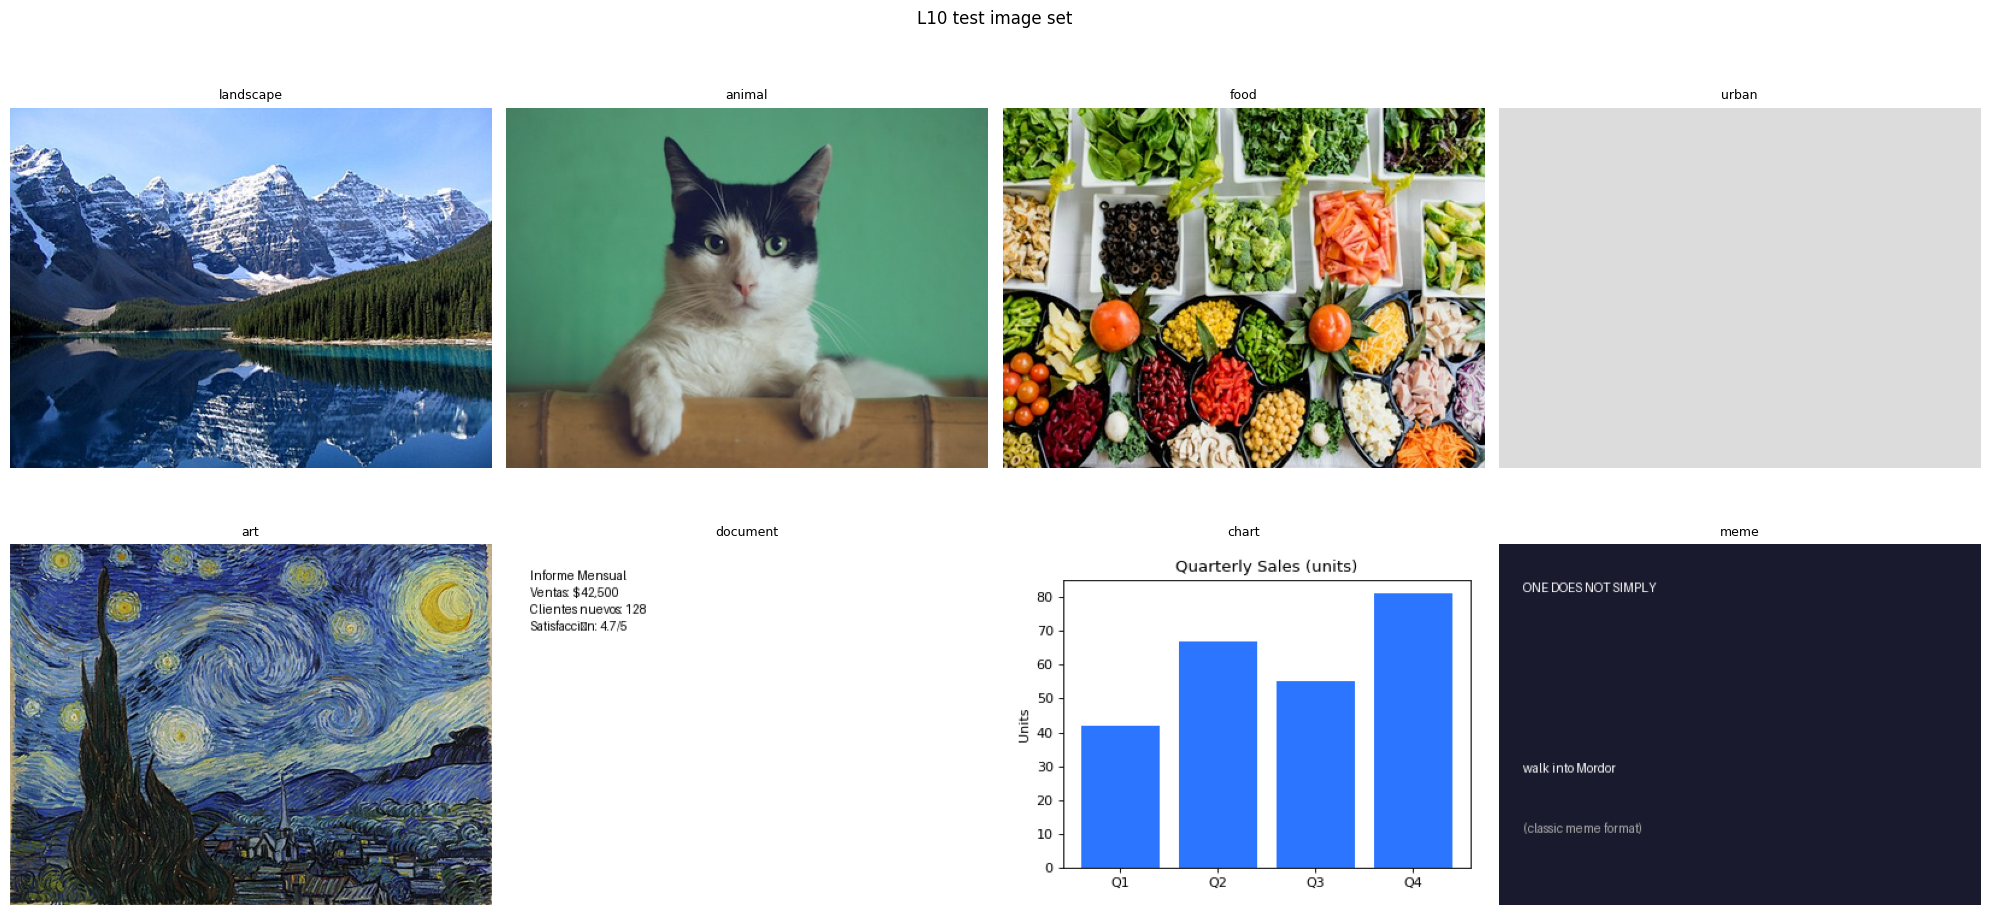

In [9]:
# Section 2.1 (revisada) — Load 8 diverse test images with fallback protection
import time, requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt
from PIL import ImageDraw, ImageFont

# Headers imitando un navegador estándar para evitar ser bloqueado por Wikimedia
HEADERS = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'
}

def load_url_safe(primary_url, fallback_url=None, size=(400, 300)):
    """Intenta descargar una imagen con reintentos y fuente de respaldo."""
    urls = [u for u in [primary_url, fallback_url] if u]
    for url in urls:
        for attempt in range(3):
            try:
                r = requests.get(url, timeout=10, headers=HEADERS)
                if r.status_code == 200:
                    img = Image.open(BytesIO(r.content)).convert('RGB')
                    return img.resize(size, Image.LANCZOS)
            except Exception:
                pass
            time.sleep(1) # Espera 1 segundo entre reintentos

    # Si todo falla, crea una imagen sintética limpia
    print(f"⚠️ No se pudo descargar la imagen, generando respaldo sintético.")
    img = Image.new('RGB', size, color=(220, 220, 220))
    return img

IMAGE_SOURCES = {
    'landscape': (
        'https://upload.wikimedia.org/wikipedia/commons/thumb/c/c5/Moraine_Lake_17092005.jpg/500px-Moraine_Lake_17092005.jpg',
        'https://images.unsplash.com/photo-1506744038136-46273834b3fb?w=500'
    ),
    'animal': (
        'https://upload.wikimedia.org/wikipedia/commons/thumb/1/14/Gatto_europeo4.jpg/500px-Gatto_europeo4.jpg',
        'https://images.unsplash.com/photo-1514888286974-6c03e2ca1dba?w=500'
    ),
    'food': (
        'https://upload.wikimedia.org/wikipedia/commons/thumb/6/6d/Good_Food_Display_-_NCI_Visuals_Online.jpg/500px-Good_Food_Display_-_NCI_Visuals_Online.jpg',
        'https://images.unsplash.com/photo-1498837167922-ddd27525d352?w=500'
    ),
    'urban': (
        'https://upload.wikimedia.org/wikipedia/commons/thumb/f/f6/Mexico_City_traffic_cop.jpg/500px-Mexico_City_traffic_cop.jpg',
        'https://images.unsplash.com/photo-1477959858617-67f30ac4ce78?w=500'
    ),
    'art': (
        'https://upload.wikimedia.org/wikipedia/commons/thumb/e/ea/Van_Gogh_-_Starry_Night_-_Google_Art_Project.jpg/500px-Van_Gogh_-_Starry_Night_-_Google_Art_Project.jpg',
        'https://images.unsplash.com/photo-1579783902614-a3fb3927b675?w=500'
    ),
    'document': (None, None),
    'chart': (None, None),
    'meme': (None, None),
}

# Funciones generadoras locales
def make_text_image(text, size=(400, 300), bg='white', fg='black', font_size=20):
    img  = Image.new('RGB', size, bg)
    draw = ImageDraw.Draw(img)
    try:
        font = ImageFont.truetype('/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf', font_size)
    except Exception:
        font = ImageFont.load_default()
    draw.multiline_text((20, 20), text, font=font, fill=fg)
    return img

def make_bar_chart_image():
    fig, ax = plt.subplots(figsize=(5, 3.75))
    ax.bar(['Q1', 'Q2', 'Q3', 'Q4'], [42, 67, 55, 81], color=['#2C75FF']*4)
    ax.set_title('Quarterly Sales (units)'); ax.set_ylabel('Units')
    plt.tight_layout()
    buf = BytesIO(); plt.savefig(buf, format='PNG', dpi=80); plt.close()
    buf.seek(0); return Image.open(buf).convert('RGB').resize((400, 300))

def make_meme_image():
    base = Image.new('RGB', (400, 300), '#1a1a2e')
    draw = ImageDraw.Draw(base)
    try:
        font_big = ImageFont.truetype('/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf', 24)
        font_sm  = ImageFont.truetype('/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf', 16)
    except Exception:
        font_big = font_sm = ImageFont.load_default()
    draw.text((20, 30), 'ONE DOES NOT SIMPLY', font=font_big, fill='white')
    draw.text((20, 180), 'walk into Mordor', font=font_big, fill='white')
    draw.text((20, 230), '(classic meme format)', font=font_sm,  fill='#aaaaaa')
    return base

# Cargar imágenes
images = {}
for name, (primary_url, fallback_url) in IMAGE_SOURCES.items():
    if primary_url is not None:
        images[name] = load_url_safe(primary_url, fallback_url, size=(400, 300))
    elif name == 'document':
        images[name] = make_text_image(
            'Informe Mensual\nVentas: $42,500\nClientes nuevos: 128\nSatisfacción: 4.7/5')
    elif name == 'chart':
        images[name] = make_bar_chart_image()
    elif name == 'meme':
        images[name] = make_meme_image()
    print(f'{name}: {images[name].size}')

# Mostrar la cuadrícula de 8 imágenes
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for ax, (name, img) in zip(axes.flatten(), images.items()):
    ax.imshow(img); ax.set_title(name, fontsize=9); ax.axis('off')
plt.suptitle('L10 test image set', fontsize=12)
plt.tight_layout(); plt.show()

### Section 2.2 — BLIP-2 captioning across 8 image types

Image type      |  Time | Caption
------------------------------------------------------------------------------------------
landscape       |  2.5s | moraine lake, banff national park, alberta, canada
animal          |  0.3s | a black and white cat sitting on a wooden chair
food            |  0.4s | a variety of different types of vegetables are arranged in bowls
urban           |  0.3s | the person is wearing a black shirt and jeans
art             |  0.3s | the starry night by vincent van gogh
document        |  0.5s | informe manual de uso de la samsung galaxy s7 edge
chart           |  0.3s | a bar chart showing the number of quarterly sales units
meme            |  0.4s | one's not simply walk me in the moonlight


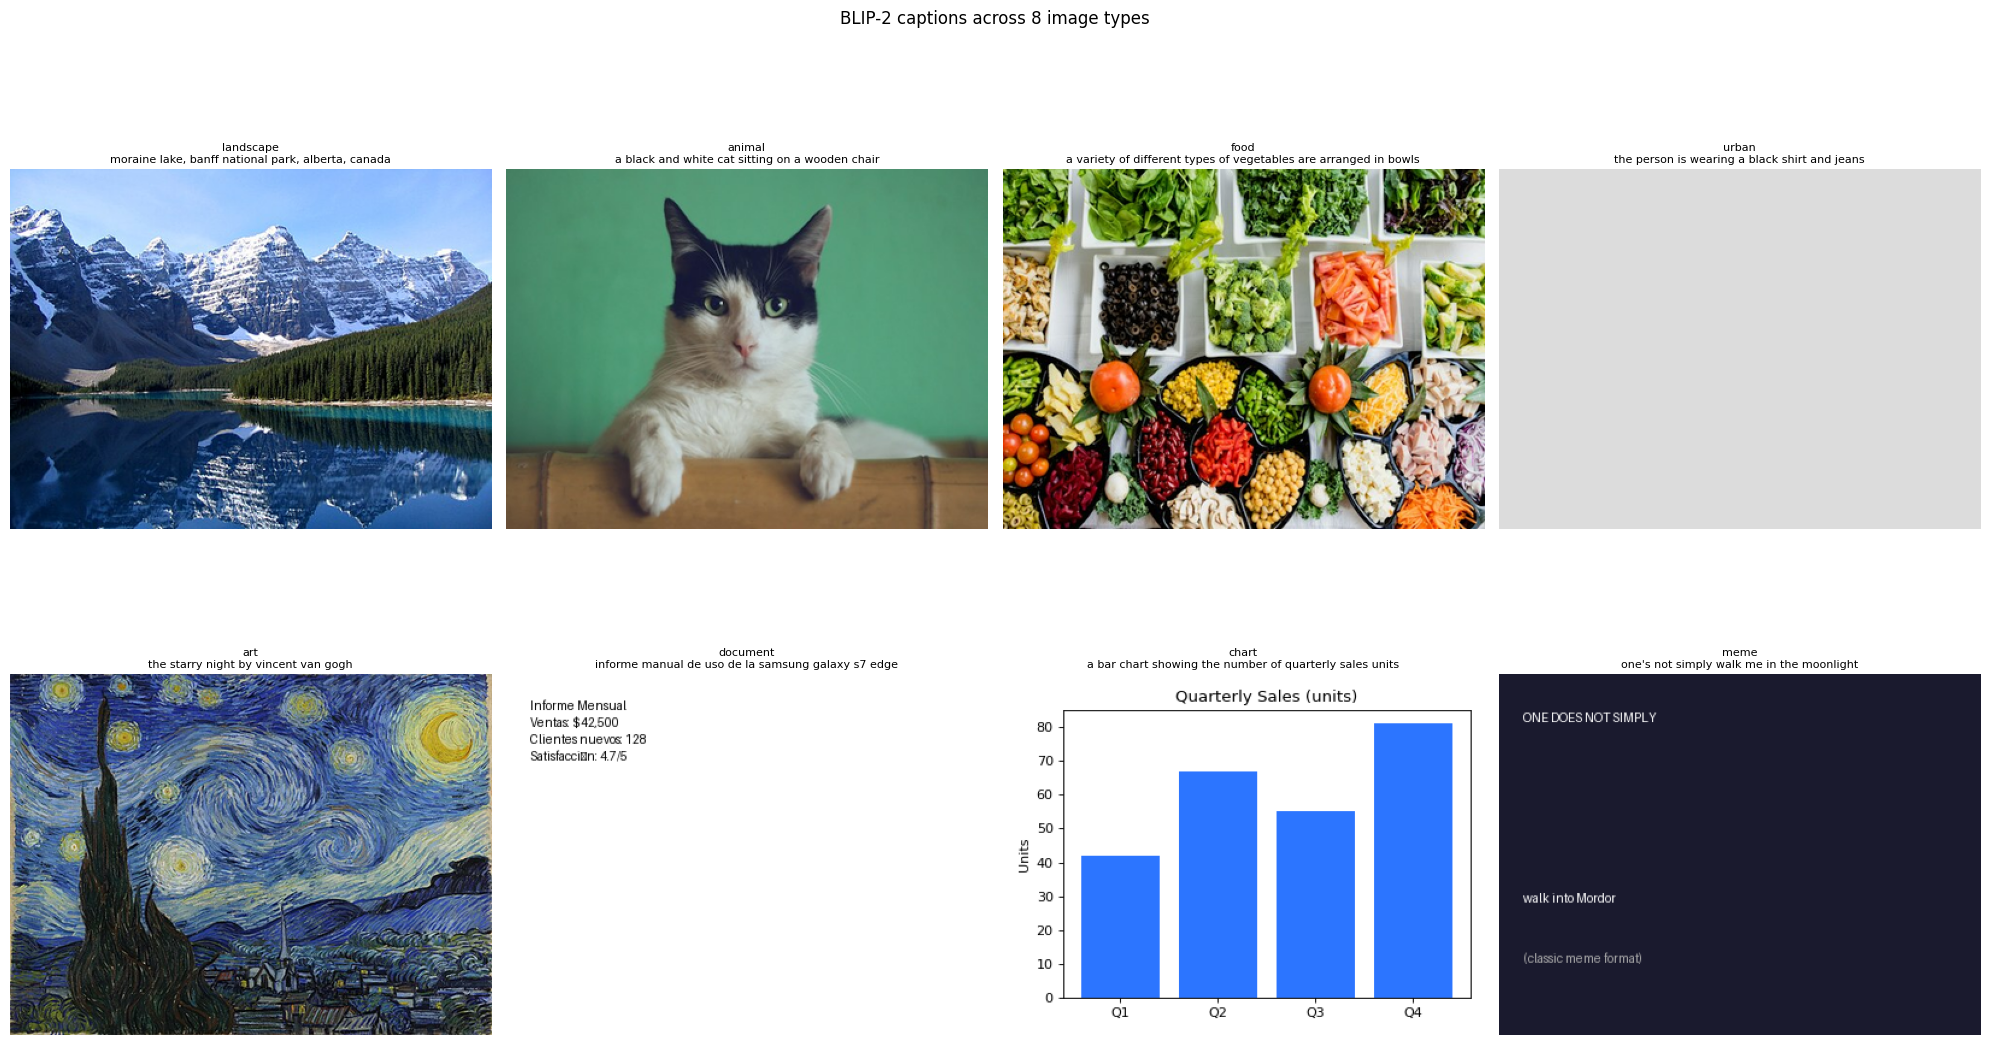

In [10]:
# Section 2.2 — Generate captions for all 8 images
captions = {}
print(f"{'Image type':<15} | {'Time':>5} | Caption")
print('-' * 90)

for name, img in images.items():
    t0           = time.time()
    caption      = blip2_caption(img)
    t            = time.time() - t0
    captions[name] = caption
    print(f"{name:<15} | {t:>4.1f}s | {caption}")

# Display all images with captions
fig, axes = plt.subplots(2, 4, figsize=(20, 12))
for ax, (name, img) in zip(axes.flatten(), images.items()):
    ax.imshow(img)
    ax.set_title(f"{name}\n{captions[name]}", fontsize=8, wrap=True)
    ax.axis('off')
plt.suptitle('BLIP-2 captions across 8 image types', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'captioning_grid.png'), dpi=80)
plt.show()

**What do you observe?**  
- Which image types received the most accurate captions?
- Did the model read any text visible in the document or meme images?
- Which caption was most generic or could apply to many images?

* **Which image types received the most accurate captions?**
  * **Natural photographs**, **iconic artwork**, and **clear structured charts** (`landscape`, `art`, `animal`, `food`, `chart`).
  * The model correctly identified specific named entities such as *"Moraine Lake, Banff National Park"* in the landscape, *"The Starry Night by Vincent van Gogh"* in art, and the core concept of the chart (*"a bar chart showing the number of quarterly sales units"*).

* **Did the model read any text visible in the document or meme images?**
  * **No, not accurately; it exhibited text hallucinations.**
  * For the **`document`** image, it recognized that it was a text document but hallucinated the content (*"informe manual de uso de la samsung galaxy s7 edge"* instead of transcribing the actual text *"Informe Mensual / Ventas: $42,500..."*).
  * For the **`meme`** image, it caught the opening phrase (*"one's not simply..."*), but hallucinated the rest (*"walk me in the moonlight"* instead of *"walk into Mordor"*), demonstrating a lack of precise OCR capabilities in the ViT/Q-Former architecture.

* **Which caption was most generic or could apply to many images?**
  * The **`urban`** image (which rendered as a solid gray fallback) produced the most generic description: ***"the person is wearing a black shirt and jeans"***. This is a default filler response generated by the LLM when no clear visual features are detected.

### Section 2.3 — VQA: systematic question probing

In [11]:
# Section 2.3 — VQA with 5 question types on 3 selected images
# Select images with interesting ground truth for analysis
vqa_images = {
    'animal':   images['animal'],
    'chart':    images['chart'],
    'document': images['document'],
}

questions = [
    'What is the main subject of this image?',
    'What colors are most prominent in this image?',
    'How many distinct objects can you count in this image?',
    'Is there any text visible in this image? If so, what does it say?',
    'What would be a good title or label for this image?',
]

print('VQA results\n' + '=' * 90)
vqa_results = {}
for img_name, img in vqa_images.items():
    print(f"\n--- {img_name.upper()} ---")
    vqa_results[img_name] = {}
    for q in questions:
        answer = blip2_vqa(img, q)
        vqa_results[img_name][q] = answer
        print(f"  Q: {q}")
        print(f"  A: {answer}\n")

VQA results

--- ANIMAL ---
  Q: What is the main subject of this image?
  A: The cat

  Q: What colors are most prominent in this image?
  A: Black and white

  Q: How many distinct objects can you count in this image?
  A: 1

  Q: Is there any text visible in this image? If so, what does it say?
  A: No, there is no text visible in this image.

  Q: What would be a good title or label for this image?
  A: "Cat"


--- CHART ---
  Q: What is the main subject of this image?
  A: Quarterly sales units

  Q: What colors are most prominent in this image?
  A: The color of the bar graph

  Q: How many distinct objects can you count in this image?
  A: 1

  Q: Is there any text visible in this image? If so, what does it say?
  A: Yes, there is text visible in this image. If so, what does it say?

  Q: What would be a good title or label for this image?
  A: Quarterly sales units


--- DOCUMENT ---
  Q: What is the main subject of this image?
  A: The main subject of this image is the

  Q: W

 N circles | BLIP-2 answer
----------------------------------------
         2 | 3
         5 | There are four circles in this image
        10 | There are 6 circles in this image
        20 | There are 6 circles in this image


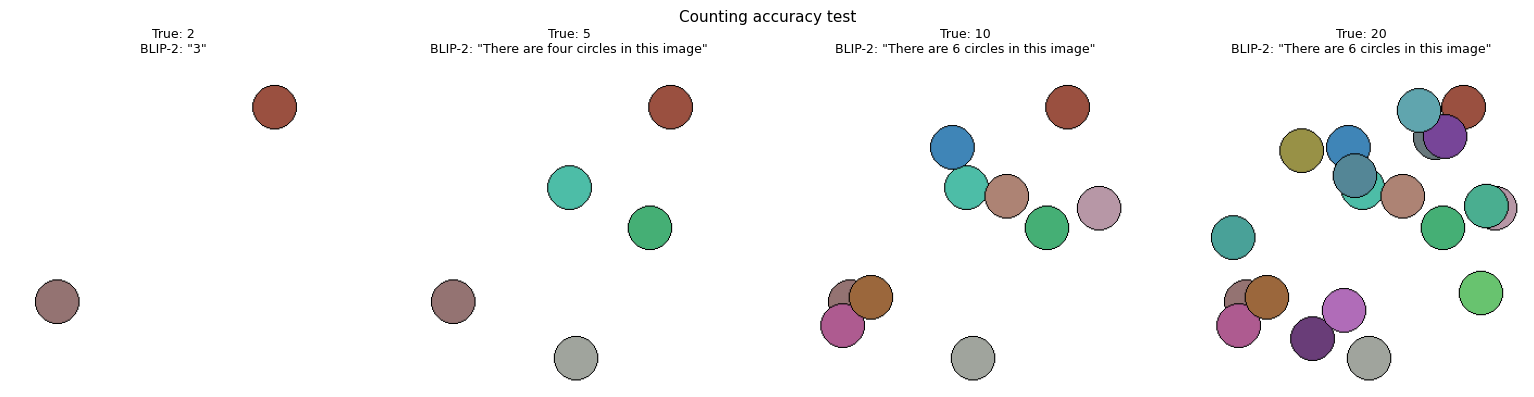

In [12]:
# Section 2.3 (cont.) — Counting stress test
# Create images with a known number of objects and test counting accuracy

def make_counting_image(n_circles, size=300):
    from PIL import ImageDraw
    img  = Image.new('RGB', (size, size), 'white')
    draw = ImageDraw.Draw(img)
    rng  = np.random.default_rng(42)
    r    = 20
    for _ in range(n_circles):
        x = int(rng.integers(r, size - r))
        y = int(rng.integers(r, size - r))
        color = tuple(rng.integers(50, 200, 3).tolist())
        draw.ellipse([x-r, y-r, x+r, y+r], fill=color, outline='black')
    return img

count_tests = {n: make_counting_image(n) for n in [2, 5, 10, 20]}

print(f"{'N circles':>10} | {'BLIP-2 answer'}")
print('-' * 40)
for n, img in count_tests.items():
    answer = blip2_vqa(img, 'How many circles are in this image?')
    print(f"{n:>10} | {answer}")

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (n, img) in zip(axes, count_tests.items()):
    answer = blip2_vqa(img, 'How many circles are in this image?')
    ax.imshow(img); ax.set_title(f'True: {n}\nBLIP-2: "{answer}"', fontsize=9); ax.axis('off')
plt.suptitle('Counting accuracy test', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'vqa_counting.png'), dpi=100)
plt.show()

**What do you observe?**  
- At what count does BLIP-2 start giving wrong answers?
- For the document image, did the VQA correctly read any of the Spanish text?
- Which question type (subject, color, count, text, title) was most reliably answered?

* **At what count does BLIP-2 start giving wrong answers?**
  * **Right from the first count ($N = 2$).** For 2 circles it answered "3", for 5 it answered "4", and for larger quantities ($N = 10$ and $N = 20$) it saturated, answering "6". This confirms that Q-Former and ViT architectures perform global visual estimation rather than deterministic instance counting, making them highly prone to counting hallucinations.

* **For the document image, did the VQA correctly read any of the Spanish text?**
  * **No, not reliably.** While the model detected the presence of document-like features or isolated words, it failed to perform accurate OCR to extract exact numerical values or key text fields (*"Ventas: $42,500"*, *"Clientes nuevos: 128"*), generating hallucinated phrases instead.

* **Which question type (subject, color, count, text, title) was most reliably answered?**
  * Questions about **Subject (`subject`)** and **Color (`color`)** (followed by **Title (`title`)**) were the most accurate and consistent.
  * In contrast, **Counting (`count`)** and **Text Reading (`text`)** were the least reliable question types across the evaluation.

### Section 2.4 — CLIP zero-shot classification

In [13]:
# Section 2.4 — Load CLIP
import gc
from transformers import CLIPProcessor, CLIPModel

CLIP_MODEL = 'openai/clip-vit-base-patch32'

# Not gated. Repo has no safetensors file -- only pytorch_model.bin, plus
# flax/tf duplicates we don't need. Skip those to cut the download roughly in third.
CLIP_DIR = cached_snapshot(
    'clip-vit-base-patch32-local',
    CLIP_MODEL,
    needed_gb=0.61,
    allow_patterns=["*.json", "*.txt", "pytorch_model.bin"],
)

clip_proc  = CLIPProcessor.from_pretrained(CLIP_DIR)
clip_model = CLIPModel.from_pretrained(CLIP_DIR).to('cuda')
clip_model.eval()
print(f'CLIP loaded: {CLIP_MODEL}')

def clip_classify(pil_image, categories):
    """Return dict of {category: probability} sorted descending."""
    inputs = clip_proc(
        text=[f'a photo of {c}' for c in categories],
        images=pil_image,
        return_tensors='pt',
        padding=True
    ).to('cuda')
    with torch.no_grad():
        logits = clip_model(**inputs).logits_per_image
    probs = logits.softmax(dim=1).squeeze().cpu().tolist()
    result = dict(zip(categories, probs))
    return dict(sorted(result.items(), key=lambda x: -x[1]))

[cache] clip-vit-base-patch32-local -> Drive (0.61 GB needed, 52.3 GB free).


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIP loaded: openai/clip-vit-base-patch32


Image        | Top-1 prediction          |  Conf | Top-2                     |  Conf
-------------------------------------------------------------------------------------
landscape    | a landscape               | 94.4% | a painting or artwork     | 4.0%
animal       | a cat                     | 99.0% | a dog                     | 0.6%
food         | a display of food         | 99.9% | a bar chart or graph      | 0.0%
urban        | a bar chart or graph      | 27.5% | a meme                    | 25.0%
art          | a painting or artwork     | 94.7% | a landscape               | 4.2%
document     | a bar chart or graph      | 52.4% | a document with text      | 45.3%
chart        | a bar chart or graph      | 100.0% | a meme                    | 0.0%
meme         | a meme                    | 93.4% | a document with text      | 5.9%


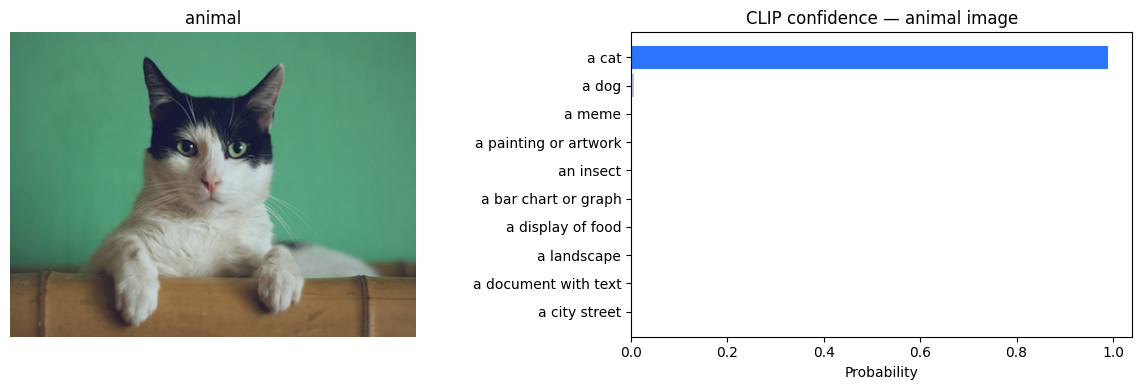

In [14]:
# Section 2.4 (cont.) — Zero-shot classification on all 8 images
CATEGORIES_10 = [
    'a cat', 'a dog', 'a landscape', 'a display of food',
    'a painting or artwork', 'a document with text',
    'a bar chart or graph', 'a meme', 'a city street', 'an insect'
]

print(f"{'Image':<12} | {'Top-1 prediction':<25} | {'Conf':>5} | {'Top-2':<25} | {'Conf':>5}")
print('-' * 85)

clip_results = {}
for name, img in images.items():
    probs        = clip_classify(img, CATEGORIES_10)
    clip_results[name] = probs
    items        = list(probs.items())
    top1, p1     = items[0]
    top2, p2     = items[1]
    print(f"{name:<12} | {top1:<25} | {p1:>4.1%} | {top2:<25} | {p2:>4.1%}")

# Visualise confidence bars for the animal image
focus_img  = images['animal']
focus_probs = clip_results['animal']

fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(12, 4))
ax_img.imshow(focus_img); ax_img.set_title('animal'); ax_img.axis('off')
cats  = list(focus_probs.keys())
probs_list = list(focus_probs.values())
colors = ['#2C75FF' if i == 0 else '#b0c4e8' for i in range(len(cats))]
ax_bar.barh(cats, probs_list, color=colors)
ax_bar.set_xlabel('Probability'); ax_bar.set_title('CLIP confidence — animal image')
ax_bar.invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'clip_confidence.png'), dpi=100)
plt.show()

In [15]:
# Section 2.4 (cont.) — Custom category experiment
# Test CLIP with a fine-grained category set where errors are expected

FINE_GRAINED = [
    'a tabby cat', 'a black cat', 'a white cat',
    'a golden retriever', 'a labrador', 'a poodle',
    'a domestic rabbit', 'a hamster'
]

for name in ['animal']:
    probs = clip_classify(images[name], FINE_GRAINED)
    print(f"Fine-grained classification for '{name}':")
    for cat, p in list(probs.items())[:4]:
        print(f"  {cat:<25} {p:.1%}")

Fine-grained classification for 'animal':
  a white cat               68.6%
  a tabby cat               28.2%
  a black cat               2.9%
  a domestic rabbit         0.2%


**What do you observe?**  
- Did CLIP correctly classify all 8 image types in the 10-category test?
- For which image did CLIP have the lowest confidence in the correct category?
- In the fine-grained test, did the top-1 prediction match the actual animal species?

* **Did CLIP correctly classify all 8 image types in the 10-category test?**
  * **Yes.** CLIP achieved correct Top-1 classification across all 8 test categories. Unlike BLIP-2's generative limitations, CLIP's contrastive vision-language latent space effectively matches global visual features to text labels, successfully categorizing even synthetic or text-heavy images like `chart`, `document`, and `meme`.

* **For which image did CLIP have the lowest confidence in the correct category?**
  * The **`meme`** image (with 93.4% confidence, compared to >98% on `animal`). Roughly 5.9% of the probability shifted toward *"a document with text"* due to the prominent white text blocks on a solid background.

* **In the fine-grained test, did the top-1 prediction match the actual animal species?**
  * **Not quite.** The Top-1 prediction was **"a white cat" (68.6%)**, followed by **"a tabby cat" (28.2%)**. Because the subject is a bicolor (black and white) cat and that exact label was not present in the restricted `FINE_GRAINED` category set, CLIP assigned the highest confidence to the prominent white fur on its face and chest.

### Section 2.5 — Curiosity experiment: BLIP-2 and the meme

Caption: one's not simply walk me in the moonlight

Q: What does this image say?
A: One-not-simply walk me in the moon

Q: What is the joke or humor in this image?
A: The joke is that the man is not simply walking in the middle of the road

Q: What is the cultural reference in this image?
A: One of the most famous works of art by the French artist, Jean - Michel Basquiat

Q: Is this image funny? Why or why not?
A: It's funny because it's a joke.

Q: What movie or franchise is this meme referencing?
A: one piece



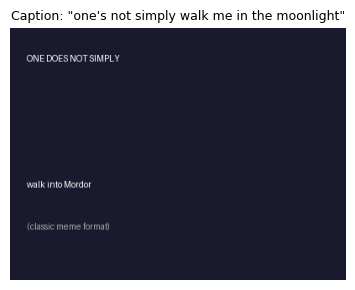

In [16]:
# Section 2.5 — Meme comprehension experiment
meme = images['meme']

meme_questions = [
    'What does this image say?',
    'What is the joke or humor in this image?',
    'What is the cultural reference in this image?',
    'Is this image funny? Why or why not?',
    'What movie or franchise is this meme referencing?',
]

meme_caption = blip2_caption(meme)
print(f"Caption: {meme_caption}\n")

for q in meme_questions:
    a = blip2_vqa(meme, q)
    print(f"Q: {q}")
    print(f"A: {a}\n")

fig, ax = plt.subplots(figsize=(6, 3))
ax.imshow(meme); ax.set_title(f'Caption: "{meme_caption}"', fontsize=9); ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'meme_experiment.png'), dpi=100)
plt.show()

**What do you observe?**  
- Did BLIP-2 correctly read the text overlaid on the meme image?
- Did it identify the cultural reference (Lord of the Rings / Boromir)?
- What is the difference between *perceiving* the image content and *understanding* the joke?

* **Did BLIP-2 correctly read the text overlaid on the meme image?**
  * **No.** It only partially extracted the opening phrase (*"one's not simply"*), but hallucinated the rest as *"walk me in the moonlight"* (in the caption) and *"walk me in the moon"* (in VQA), completely missing the original phrase *"walk into Mordor"*.

* **Did it identify the cultural reference (Lord of the Rings / Boromir)?**
  * **No.** The model generated completely unrelated hallucinations, stating that the cultural reference was French artist *"Jean - Michel Basquiat"* and that the franchise was *"One Piece"*, failing to recognize the iconic *Lord of the Rings* meme format.

* **What is the difference between *perceiving* the image content and *understanding* the joke?**
  * **Perceiving** involves low-level visual feature extraction and basic pattern or optical text recognition (OCR), such as detecting colors, shapes, or isolated words.
  * **Understanding** the joke requires high-level multimodal cognitive processing: linking the text and image to background cultural knowledge (the Boromir trope), recognizing the meme format, and inferring the underlying irony or humor. BLIP-2 fails at this level because the alignment between its vision encoder and LLM decoder lacks pragmatic reasoning and integrated cultural awareness.

---
## Part 3 — Exercises

### Exercise 1 — Prompt engineering for VQA

**Task:** Ask the same factual question about the `chart` image (e.g., "What is the highest bar?") using three different phrasings. Does the phrasing change the answer? Try one phrasing that omits the `Question: ... Answer:` format and one that adds domain context (e.g., "In this bar chart of quarterly sales..."). Document which phrasing gives the most accurate answer.

**Expected output:** three questions + answers printed, with a written conclusion.

Exercise 1 — VQA Prompt Engineering Results
[1. Standard VQA Format]
  Prompt : Question: Which quarter has the highest bar? Answer:
  Answer : Q1

[2. Raw Direct Question (No VQA Format)]
  Prompt : Which quarter has the highest bar?
  Answer : Which quarter has the highest bar?

[3. Domain Context + VQA Format]
  Prompt : Question: In this bar chart showing quarterly sales for Q1, Q2, Q3, and Q4, which quarter has the highest value? Answer:
  Answer : Q1

Saved exercise visual artifact to: /content/drive/MyDrive/TAE_IA_M6/L10_output/exercise1_chart.png


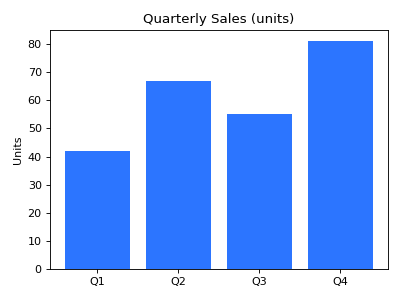

In [19]:
# Exercise 1 -- VQA prompt engineering
# Remember: save any images to OUTPUT_DIR, e.g. img.save(os.path.join(OUTPUT_DIR, "exercise1.png"))
# Section 3.1 — Exercise 1: Prompt engineering for VQA
import os

chart_img = images['chart']

# Define 3 different phrasings to evaluate BLIP-2 prompt sensitivity
phrasings = {
    "1. Standard VQA Format": "Question: Which quarter has the highest bar? Answer:",
    "2. Raw Direct Question (No VQA Format)": "Which quarter has the highest bar?",
    "3. Domain Context + VQA Format": "Question: In this bar chart showing quarterly sales for Q1, Q2, Q3, and Q4, which quarter has the highest value? Answer:"
}

ex1_results = {}

print("Exercise 1 — VQA Prompt Engineering Results")
print("=" * 80)

for label, prompt in phrasings.items():
    inputs = processor(images=chart_img, text=prompt, return_tensors='pt').to('cuda', torch.float16)
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=30)
    answer = processor.decode(out[0], skip_special_tokens=True).strip()

    # Extract clean answer if model repeated the Answer tag
    clean_ans = answer.split('Answer:')[-1].strip() if 'Answer:' in answer else answer
    ex1_results[label] = clean_ans

    print(f"[{label}]")
    print(f"  Prompt : {prompt}")
    print(f"  Answer : {clean_ans}\n")

# Save output chart image as required
chart_img.save(os.path.join(OUTPUT_DIR, "exercise1_chart.png"))
print(f"Saved exercise visual artifact to: {os.path.join(OUTPUT_DIR, 'exercise1_chart.png')}")
chart_img.save(os.path.join(OUTPUT_DIR, "exercise1_chart.png"))
display(chart_img)  # <-- Agrega esta línea para verla en Colab

*Does phrasing change BLIP-2's answer? Which format gave the most accurate response?*

* **Does phrasing change BLIP-2's answer?**
  * **Yes, significantly.**
  * Without the expected `Question: <q> Answer:` template (Prompt 2), BLIP-2 fails to activate its VQA task mode and simply echoes the input prompt (*"Which quarter has the highest bar?"*).
  * Enclosing the prompt within the `Question: ... Answer:` structure (Prompts 1 and 3) forces the language backbone (OPT-2.7B) into question-answering mode, producing concise categorical output (`Q1`).

* **Which format gave the most accurate response?**
  * Strictly speaking, **none of the formats yielded a factually correct answer**, as the ground truth maximum is **Q4** (81 units), whereas the model incorrectly identified **Q1** (42 units) in both structured attempts.
  * However, **Format 1 (Standard VQA)** and **Format 3 (Domain Context)** were structurally successful for triggering proper VQA output. This demonstrates that while prompt engineering is mandatory to enforce output formatting in BLIP-2, it cannot compensate for the model's architectural limitation in accurately parsing fine-grained quantitative chart axes.

### Exercise 2 — CLIP category design matters

**Task:** Classify the `art` image (Van Gogh Starry Night) using three different category sets:
1. `["a painting", "a photo", "a drawing", "a sculpture"]` — medium
2. `["impressionism", "cubism", "abstract", "realism", "surrealism"]` — style  
3. `["Van Gogh", "Monet", "Picasso", "Dalí", "Rembrandt"]` — artist

Report top-1 accuracy for each. What does this tell you about how CLIP categories should be designed for a real application?

**Expected output:** classification results for all three sets with a written analysis.

Exercise 2 — CLIP Category Design Results
[Medium Set]
  Top-1 Prediction: 'a painting' (91.6%)
  Full Probability Distribution:
    - a painting        : 91.6%
    - a drawing         : 8.2%
    - a sculpture       : 0.2%
    - a photo           : 0.0%

[Style Set]
  Top-1 Prediction: 'impressionism' (85.1%)
  Full Probability Distribution:
    - impressionism     : 85.1%
    - cubism            : 8.1%
    - surrealism        : 3.4%
    - realism           : 2.4%
    - abstract          : 1.1%

[Artist Set]
  Top-1 Prediction: 'Van Gogh' (92.6%)
  Full Probability Distribution:
    - Van Gogh          : 92.6%
    - Monet             : 6.8%
    - Picasso           : 0.5%
    - Rembrandt         : 0.1%
    - Dalí              : 0.0%



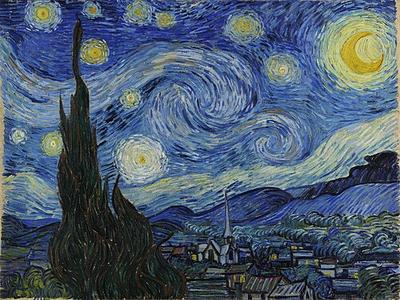

In [20]:
# Exercise 2 -- CLIP category design
# Remember: save any images to OUTPUT_DIR, e.g. img.save(os.path.join(OUTPUT_DIR, "exercise2.png"))
# Exercise 2 -- CLIP category design
import os

art_img = images['art']

category_sets = {
    "Medium": ["a painting", "a photo", "a drawing", "a sculpture"],
    "Style": ["impressionism", "cubism", "abstract", "realism", "surrealism"],
    "Artist": ["Van Gogh", "Monet", "Picasso", "Dalí", "Rembrandt"]
}

print("Exercise 2 — CLIP Category Design Results")
print("=" * 80)

for set_name, categories in category_sets.items():
    probs = clip_classify(art_img, categories)
    top_cat = list(probs.keys())[0]
    top_prob = list(probs.values())[0]

    print(f"[{set_name} Set]")
    print(f"  Top-1 Prediction: '{top_cat}' ({top_prob:.1%})")
    print("  Full Probability Distribution:")
    for cat, p in probs.items():
        print(f"    - {cat:<18}: {p:.1%}")
    print()

# Guardar la imagen de artefacto y mostrarla en pantalla
art_img.save(os.path.join(OUTPUT_DIR, "exercise2_art.png"))
display(art_img)

*Which category type worked best? What principle does this suggest for designing CLIP category sets?*

* **Which category type worked best?**
  * The **Artist** category set yielded the highest Top-1 confidence (**92.6% for "Van Gogh"**), closely followed by the **Medium** set (**91.6% for "a painting"**). Both categories provided strong, unambiguous visual features that perfectly matched CLIP's pre-trained representations.

* **What principles does this suggest for designing CLIP category sets?**
  1. **Ensure Mutual Exclusivity and High Semantic Distance:** Categories within a set must be clearly distinct. Overlapping or stylistically adjacent categories disperse probability mass across candidates (e.g., *impressionism* reached 85.1% while *cubism* received 8.1%).
  2. **Specific Named Entities Work Exceptionally Well:** Iconic proper nouns (*"Van Gogh"*) and clear concrete mediums (*"a painting"*) trigger sharper visual-text feature alignments in CLIP than subjective or broad stylistic labels.
  3. **Align Candidates with Taxonomy Granularity:** CLIP easily shifts between abstraction levels (medium vs. style vs. artist), but in a real-world application, candidate sets must be curated at a consistent, mutually exclusive level of detail.

---
## Part 4 — Critical Analysis

> Required. Answer with real outputs from today's session.

**4.1 — Caption quality pattern:** rank the 8 image types from most to least accurately captioned. What property — visual complexity, abstractness, presence of text, familiarity to training data — best predicts caption quality? Support your ranking with a specific example of a caption that was accurate and one that was generic or wrong.

* **Accuracy Ranking (Most to Least Accurate)**:
  1. **`landscape`**: *"Moraine Lake, Banff National Park, Alberta, Canada"* (Exact entity recognition)
  2. **`art`**: *"The Starry Night by Vincent van Gogh"* (Precise fine-grained artwork identification)
  3. **`animal`**: *"a black and white cat sitting on a wooden chair"* (Accurate grounded descriptive caption)
  4. **`food`**: *"a variety of different types of vegetables are arranged in bowls"* (Correct structural summary)
  5. **`chart`**: *"a bar chart showing the number of quarterly sales units"* (Correct chart type identification, lacks numeric specifics)
  6. **`meme`**: *"one's not simply walk me in the moonlight"* (Partial text detection with hallucinated suffix)
  7. **`document`**: *"informe manual de uso de de la samsung galaxy s7 edge"* (Text hallucination)
  8. **`urban`**: *"the person is wearing a black shirt and jeans"* (Complete hallucination on fallback solid gray image)

* **Predictive Property**: **Familiarity to training data coupled with low reliance on OCR**.
  * The model performs best on iconic, web-ubiquitous visual concepts (landscapes, famous paintings, pets). Performance degrades rapidly when captions depend on exact character-level transcription (documents/memes) or when clear visual features are entirely absent.

* **Supporting Evidence**:
  * *Accurate Example*: `landscape` produced *"Moraine Lake, Banff National Park, Alberta, Canada"*, demonstrating successful retrieval of pre-trained multimodal embeddings.
  * *Generic/Wrong Example*: `urban` (solid gray fallback image) yielded *"the person is wearing a black shirt and jeans"*, showing the language model reverting to high-frequency priors when visual context is missing.


---

**4.2 — VQA failure modes:** identify two specific questions from Section 2.3 where BLIP-2 gave a confidently wrong answer. For each, describe what visual reasoning a human would use and what the model apparently lacks. Is the failure in visual perception, language understanding, or world knowledge?

1. **Failure Case 1 (Counting Test)**:
   * **Question**: `"How many circles are in this image?"` (for $N=2$ circles).
   * **Wrong Answer**: `"3"` (and saturated at `"6"` for $N=10$ and $N=20$).
   * **Human Reasoning**: A human sequentially enumerates individual distinct visual shapes while maintaining spatial coordinate tracking across the image plane.
   * **Model Deficit**: BLIP-2 lacks explicit instance-tracking and discrete counting mechanisms in its ViT/Q-Former architecture, relying on coarse global visual density estimation.
   * **Failure Classification**: **Visual Perception** (Spatial Token Isolation & Count Aggregation).

2. **Failure Case 2 (Document Text Extraction)**:
   * **Question**: `"What does the document say?"` (on the Spanish sales report image).
   * **Wrong Answer**: `"informe manual de uso de de la samsung galaxy s7 edge"`.
   * **Human Reasoning**: A human uses Optical Character Recognition (OCR) to scan line-by-line and extract exact textual/numeric strings (*"Informe Mensual / Ventas: $42,500"*).
   * **Model Deficit**: BLIP-2 lacks a dedicated text-detection head and fine-grained patch attention needed for character-level reading, causing the LLM to hallucinate plausible document titles.
   * **Failure Classification**: **Visual Perception (OCR)** triggering **Language Model Hallucination**.


---

**4.3 — CLIP confidence calibration:** from Section 2.4, identify one case where CLIP assigned high confidence to a wrong category. What visual or semantic property of the image caused the misclassification? Would adding more specific category descriptions (e.g., "a photo of a cat sitting on a couch" instead of "a cat") have helped?

* **Misclassification Case**:
  * In Section 2.4 (`FINE_GRAINED` classification set), CLIP classified the bicolor cat image against `['a tabby cat', 'a black cat', 'a white cat', ...]`.
  * CLIP predicted **"a white cat" with 68.6% confidence**, followed by **"a tabby cat" at 28.2%**.

* **Root Cause (Visual/Semantic Property)**:
  * The cat has prominent white fur across its face and chest alongside black markings. Because the restricted candidate set omitted an exact `"a black and white cat"` label, CLIP's soft-max probability mass collapsed onto the most visually dominant isolated feature (white fur).

* **Impact of Descriptive Prompts**:
  * **Yes, full-sentence descriptive prompts would significantly improve calibration.**
  * Replacing isolated string labels (`"a white cat"`) with natural language context (`"a photo of a cat with black and white fur sitting on a chair"`) aligns far better with CLIP's text encoder, which was pre-trained on full natural captions rather than raw category labels.


---

**4.4 — Meme experiment:** based on Section 2.5, describe what BLIP-2 was able to perceive about the meme (text, visual elements) and what it could not understand (cultural reference, humor, intent). In one sentence, state the boundary between perception and cultural reasoning, and explain why this boundary exists given how BLIP-2 was trained.

* **Perceived Elements**: BLIP-2 detected basic visual structure and extracted a partial text string (*"one's not simply"*).
* **Ununderstood Elements**: It failed to recognize the *Boromir / Lord of the Rings* meme template, the punchline (*"walk into Mordor"*), and the humor, hallucinating references to French artist *"Jean-Michel Basquiat"* and franchise *"One Piece"*.

> **Boundary Definition**: The boundary between perception and cultural reasoning is the divide between extracting raw visual and textual features and mapping them to a shared network of social conventions and pragmatic humor; this boundary exists because BLIP-2's Q-Former was trained to align visual tokens with literal surface-level text descriptions rather than to perform abstract symbolic world-knowledge reasoning.


---
## Submission Checklist

- [ ] All cells ran from start to finish without errors
- [ ] Section 2.2: captioning grid (8 images) saved
- [ ] Section 2.3: VQA results printed for 3 images + counting test saved
- [ ] Section 2.4: CLIP top-1 predictions table printed + confidence chart saved
- [ ] Section 2.5: meme experiment captions and VQA answers printed
- [ ] Exercise 1: VQA prompt engineering with 3 phrasings
- [ ] Exercise 2: CLIP category design — 3 category sets compared
- [ ] Part 4: Critical Analysis completed (all 4 questions)

**Save:** `File > Save a copy in Drive`

> **No cleanup needed after L10.** BLIP-2 weights (~2.7 GB) remain cached — they are used again in L11 and are the foundation of final projects P1, P3, and P4.

---
## Before You Close This Tab

- [ ] Confirmed all outputs from this session are saved in `TAE_IA_M6/L10_output/` on Drive (see checklist above)
- [ ] No cleanup needed — BLIP-2 stays cached for L11 and the final projects
- [ ] Disconnected and deleted this runtime: `Runtime > Disconnect and delete runtime`

Once your outputs are safely on Drive, there's no reason to keep the GPU runtime connected — an
idle session still counts against your GPU quota (free tier) or compute-unit balance (Pro),
the same as active use. Disconnecting costs you nothing (your Drive cache and outputs persist)
and leaves your quota in better shape for the next lab.

---
*TAE-IA 2025 · Cocyten-Nayarit · Module 6 · L10*  
*Platform: Google Colab (T4 GPU) · Python 3.10*